In [3]:
import numpy as np
from sklearn import datasets
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [12, 4]

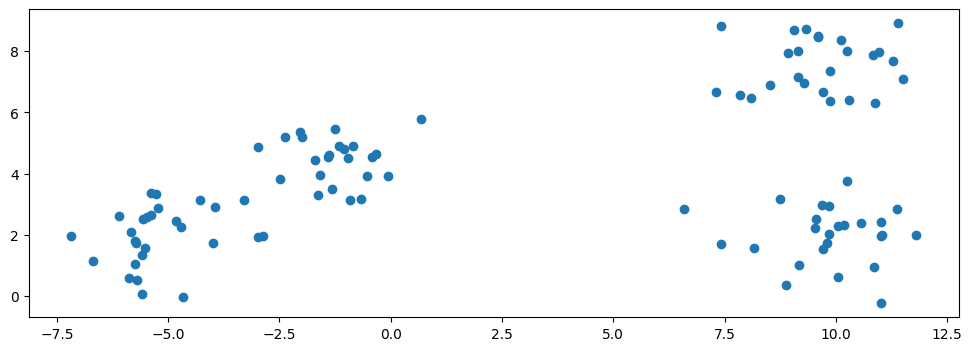

In [4]:
X, y = datasets.make_blobs(centers=4)
plt.scatter(X[:,0], X[:,1])

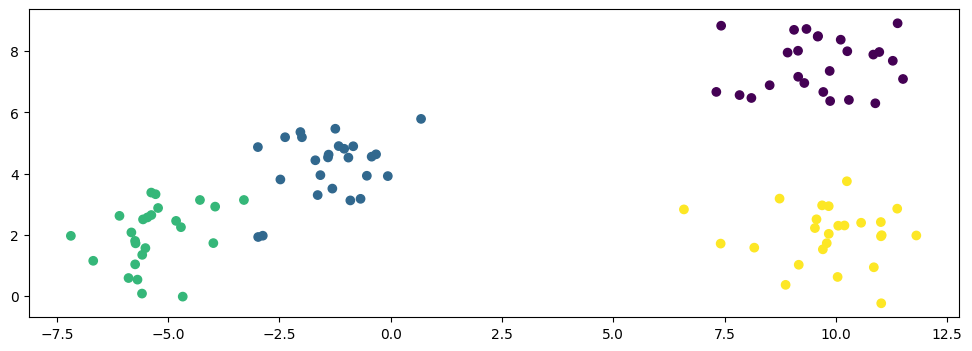

In [5]:
plt.scatter(X[:,0], X[:,1], c=y)


In [6]:
from sklearn import cluster
model = cluster. KMeans(n_clusters=2)
model.fit(X)

KMeans(n_clusters=2)

K-Means Objective: 842.62


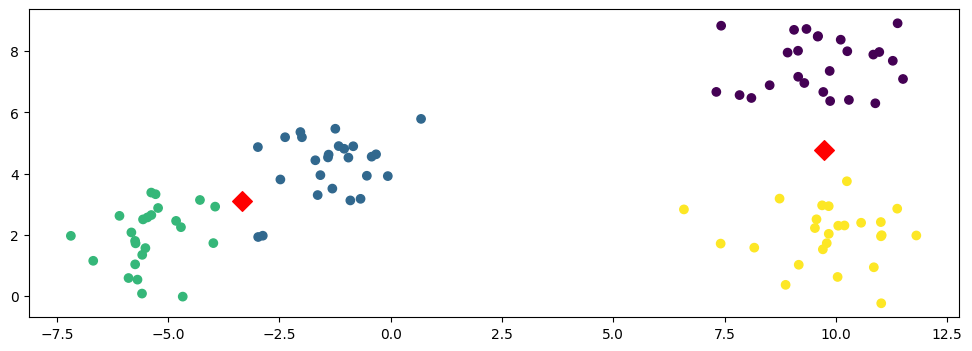

In [8]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], marker='D', c='r', s=100)
print('K-Means Objective: %.2f' % -model.score(X))

Text(0.5, 1.0, 'K-Means Objective: 40.71')

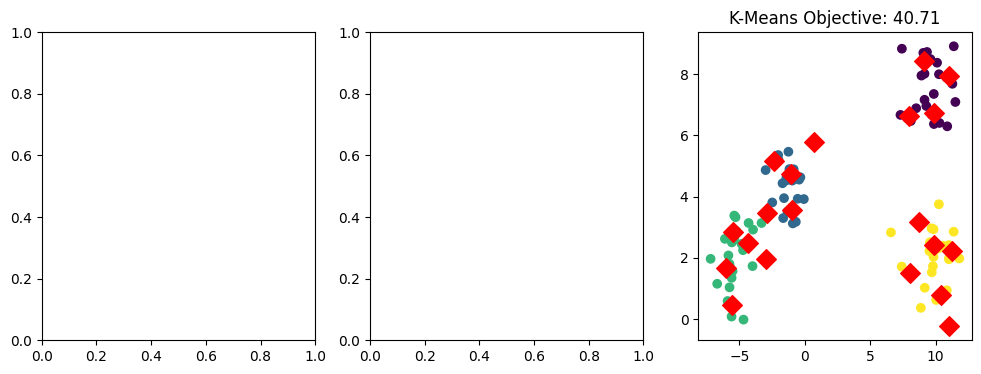

In [10]:
Ks = [4, 10, 20]
f, axes = plt.subplots(1,3)
for k, ax in zip(Ks, axes):
# Fit K-means
  model = cluster.KMeans(n_clusters=k)
  model.fit(X)
# Visual both the datapoints and the k learned clusters
ax.scatter(X[:,0], X[:,1], c=y)
ax.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], marker='D', c='r', s=100)
ax.set_title('K-Means Objective: %.2f' % -model.score(X))

K-Means Objective: 5.63


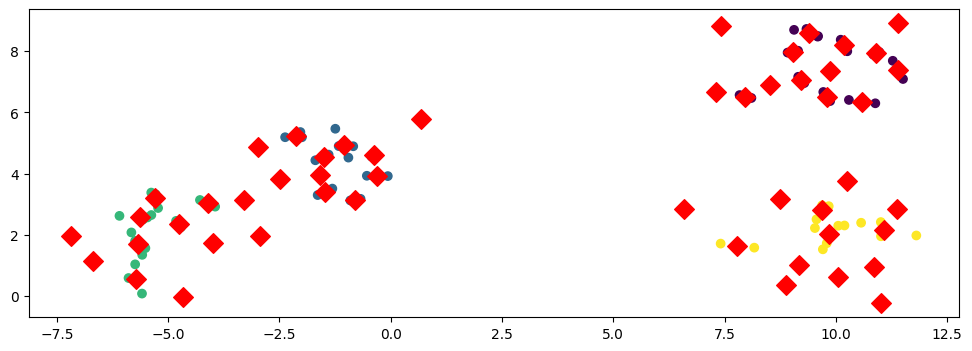

In [11]:
# Setting K = 50
model = cluster.KMeans(n_clusters=50)
# Fit K-means
model.fit(X)
# Visualize both the datapoints and the learned clusters
plt.scatter(X[:,0], X[:,1], c=y)
plt.scatter(model.cluster_centers_[:, 0], model. cluster_centers_[: , 1], marker='D', c='r', s=100)
print('K-Means Objective: %.2f' % -model.score(X))

Text(0.5, 1.0, 'Overfitting')

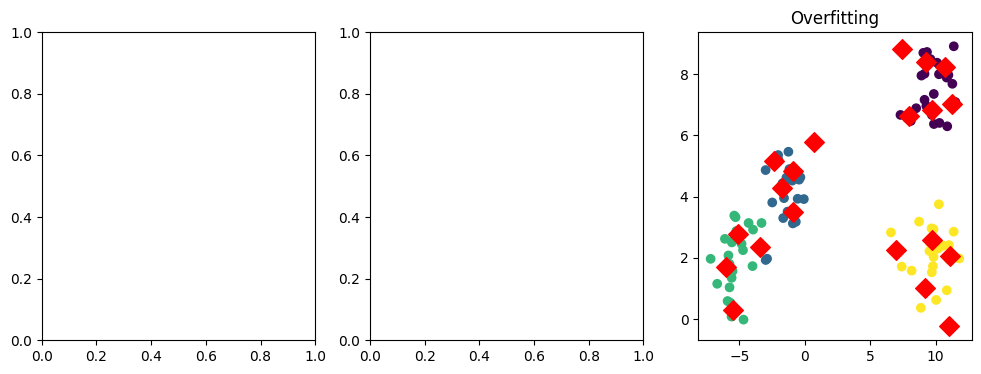

In [16]:
Ks, titles = [2, 4, 20], ['Underfitting', 'Good fit', 'Overfitting' ]
f, axes = plt.subplots(1,3)
for k, title, ax in zip(Ks, titles, axes):
  model = cluster. KMeans(n_clusters=k)
  model.fit(X)
ax.scatter(X[:,0], X[:,1], c=y)
ax.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], marker='D', c='r', s=100)
ax.set_title(title)

Text(0, 0.5, 'Objective Function Value')

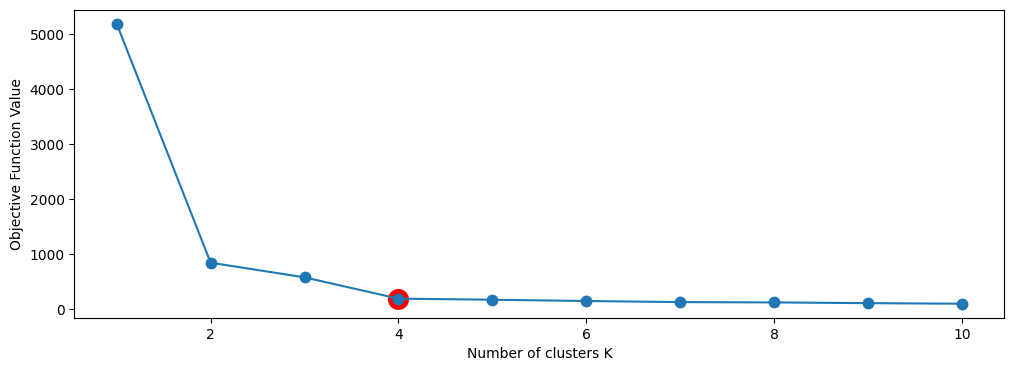

In [19]:
#the elbow method
Ks, objs = range(1,11), []
for k in Ks:
  model = cluster.KMeans(n_clusters=k)
  model.fit(X)
  objs.append(-model.score(X))

plt.plot(Ks, objs, '.-', markersize=15)
plt.scatter([4], [objs[3]], s=200, c='r')
plt.xlabel("Number of clusters K")
plt.ylabel("Objective Function Value")

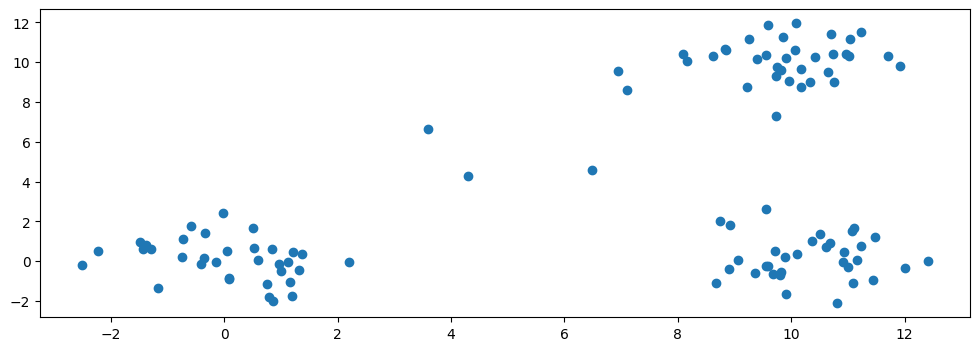

In [20]:
import sklearn.datasets as sk_data
import numpy as np
import matplotlib.pyplot as plt

blobs_x, cluster_labels = sk_data.make_blobs(centers=[[0,0],[10,10], [10,0]])

# 5 anomaly data
anomalies, _= sk_data.make_blobs(centers=[[5,5]], n_samples=5, cluster_std=3, random_state=42)

data = np.concatenate([blobs_x, anomalies])
cluster_labels = np.concatenate([cluster_labels, [-1]*len(anomalies)])

plt.plot(data[:,0], data[:,1], 'o')
plt.show()

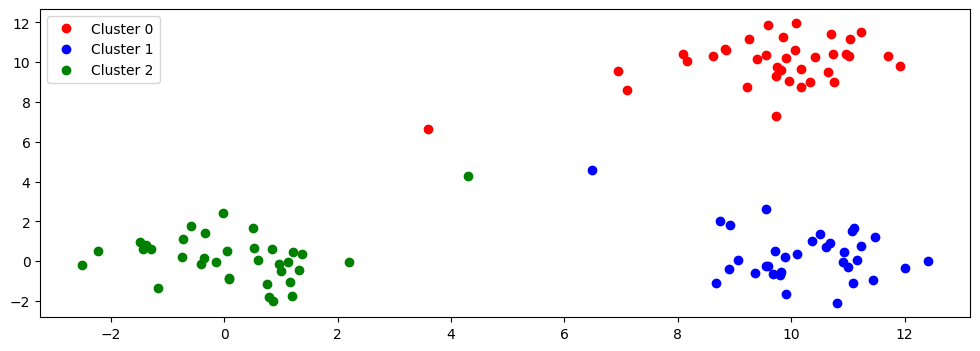

In [21]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
kmeans.fit(data)
y_pred = kmeans.predict(data)

plt.plot(data[y_pred == 0, 0], data[y_pred == 0, 1], 'ro', label='Cluster 0')
plt.plot(data[y_pred == 1, 0], data[y_pred == 1, 1], 'bo', label='Cluster 1')
plt.plot(data[y_pred == 2, 0], data[y_pred == 2, 1], 'go', label='Cluster 2')
plt.legend()
plt.show()

In [22]:
centers = kmeans. cluster_centers_[y_pred]
centers[:10]

array([[ 0.17608554,  0.18905193],
       [ 0.17608554,  0.18905193],
       [ 0.17608554,  0.18905193],
       [ 0.17608554,  0.18905193],
       [10.19578312,  0.31815922],
       [ 0.17608554,  0.18905193],
       [ 9.6669012 ,  9.99676177],
       [ 9.6669012 ,  9.99676177],
       [ 0.17608554,  0.18905193],
       [10.19578312,  0.31815922]])

In [23]:
score = np.linalg.norm(data - centers, axis=1)
score # distance of each samples to its cluster centroid

array([1.73188497, 1.3205535 , 0.78303508, 1.28110232, 1.0797806 ,
       1.06223287, 2.26079156, 1.0100387 , 2.30071596, 1.00701439,
       2.094348  , 1.10995601, 1.7943495 , 2.70290894, 0.71232103,
       0.77134306, 2.24438959, 0.67303965, 2.06878077, 0.81000636,
       0.32345768, 1.11754675, 1.55480642, 1.19544815, 0.51509124,
       1.30743915, 1.31045659, 1.58332748, 1.24191498, 1.16129331,
       0.44819829, 0.57806939, 1.67509359, 1.02939391, 0.34533918,
       0.99154871, 1.6569532 , 1.21073847, 1.16064281, 1.38936913,
       2.42758098, 0.37917232, 1.76835578, 0.32542576, 1.63355012,
       1.05636103, 1.09594342, 1.12156222, 0.91297634, 2.36340301,
       0.34278534, 2.2043381 , 2.09899563, 2.07139213, 0.26948691,
       1.26946518, 2.2155929 , 0.60540042, 0.09947513, 1.75180769,
       2.00894022, 1.83022249, 1.45873226, 1.96176997, 1.3272909 ,
       0.57050803, 0.68081518, 1.07330246, 1.10470582, 2.51777115,
       0.74981579, 1.5321408 , 1.53083905, 1.099003  , 2.23592

In [24]:
# sort the score, the largest distances of first 5 are the anomaly samples
anomaly_idx = np.argsort(score)[ ::- 1][0:5] # descending sort
anomaly_idx

array([102, 100, 103,  94, 101])

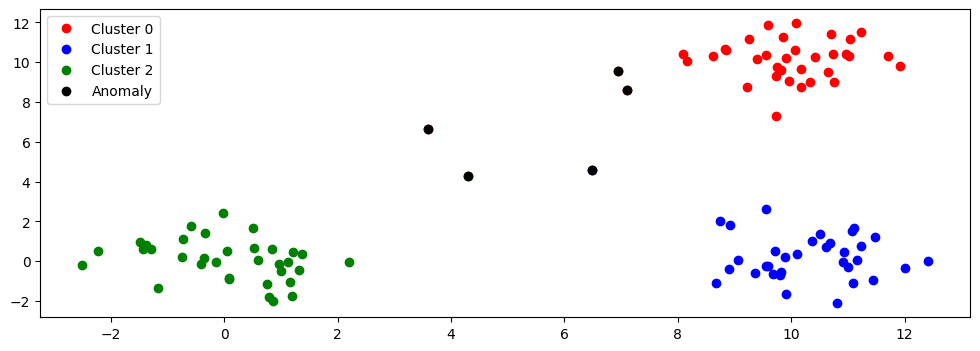

In [25]:
#mark the outliers in graph
plt.plot(data[y_pred == 0, 0], data[y_pred == 0, 1], 'ro', label='Cluster 0')
plt.plot(data[y_pred == 1, 0], data[y_pred == 1, 1], 'bo', label='Cluster 1')
plt.plot(data[y_pred == 2, 0], data[y_pred == 2, 1], 'go', label='Cluster 2')

plt.plot(data[anomaly_idx, 0],
data[anomaly_idx, 1],
marker = 'o',
linestyle='none',
color='k',
label='Anomaly')
plt.legend()
plt.show()

**Lab10B**

In [26]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [27]:
# Simulate a Titanic dataset
data = {
    'Pclass': [3, 1, 3, 1, 3],
    'Sex': ['male', 'female', 'female', 'female', 'male'],
    'Age': [22, 38, 26, 35, np.nan],
    'SibSp': [1, 1, 0, 1, 0],
    'Parch': [0, 0, 0, 0, 0],
    'Fare': [7.25, 71.2833, 7.925, 53.1, 8.05]
}
train = pd.DataFrame(data)
train


In [30]:
# 3a: Include 'Sex' (encoded) and numerical features
numerical_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
train['Age'].fillna(train['Age'].median(), inplace=True)  # Fill missing Age

# Encode 'Sex'
le = LabelEncoder()
train['Sex_encoded'] = le.fit_transform(train['Sex'])

# Create feature set with 'Sex'
X_with_sex = train[numerical_features + ['Sex_encoded']]

# 3b: Feature set without 'Sex'
X_without_sex = train[numerical_features]

# Standardize features
scaler = StandardScaler()
scaled_with_sex = scaler.fit_transform(X_with_sex)
scaled_without_sex = scaler.fit_transform(X_without_sex)

<ipython-input-30-629ae7a68757>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)  # Fill missing Age


KeyError: "['SibSp', 'Parch'] not in index"

In [ ]:
# Calculate WCSS for k=1 to 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_with_sex)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [ ]:
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_with_sex)

# Silhouette Score
silhouette_avg = silhouette_score(scaled_with_sex, cluster_labels)
print(f"Silhouette Score (with Sex): {silhouette_avg:.2f}")

In [ ]:
# Repeat for features without 'Sex'
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_without_sex)
silhouette_avg = silhouette_score(scaled_without_sex, cluster_labels)
print(f"Silhouette Score (without Sex): {silhouette_avg:.2f}")

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(scaled_with_sex)

# Adjusted Rand Score
ars = adjusted_rand_score(train['Survived'], gmm_labels)
print(f"Adjusted Rand Score (GMM): {ars:.2f}")

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(scaled_with_sex)

# Count clusters and outliers
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"Clusters: {n_clusters}, Outliers: {sum(db_labels == -1)}")

In [ ]:
from sklearn.datasets import load_iris

data = load_iris()
X = data.data  # Features
y = data.target  # True labels

In [ ]:
plt.figure(figsize=(9, 3.5))
plt.subplot(1, 2, 1)
plt.scatter(X[y == 0, 2], X[y == 0, 3], c='red', label='Setosa')
plt.scatter(X[y == 1, 2], X[y == 1, 3], c='blue', label='Versicolor')
plt.scatter(X[y == 2, 2], X[y == 2, 3], c='green', label='Virginica')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X[:, 2], X[:, 3], c='k', marker='.')
plt.xlabel('Petal Length')
plt.tick_params(labelleft=False)
plt.show()

In [ ]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.title('Elbow Method for Iris')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X)

# Silhouette Score
silhouette = silhouette_score(X, cluster_labels)
print(f"Silhouette Score: {silhouette:.2f}")  # Output: ~0.55

In [ ]:
# Map clusters to true labels
cluster_to_label = {}
for cluster in set(cluster_labels):
    mask = (cluster_labels == cluster)
    majority_label = pd.Series(y[mask]).mode()[0]
    cluster_to_label[cluster] = majority_label

predicted_labels = [cluster_to_label[c] for c in cluster_labels]

# Confusion Matrix
cm = confusion_matrix(y, predicted_labels)
print("Confusion Matrix:\n", cm)

# Adjusted Rand Score
ars = adjusted_rand_score(y, cluster_labels)
print(f"Adjusted Rand Score: {ars:.2f}")  # Output: ~0.73

In [ ]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)

ars = adjusted_rand_score(y, gmm_labels)
print(f"Adjusted Rand Score (GMM): {ars:.2f}")  # Output: ~0.90